In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv(
    r'C:\Users\HP\Downloads\Data Analytics Projects\Final Projects\Telecom_Churn_Analysis\outputs\cleaned_data.csv'
)

In [5]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Tenure Groups,Risk Level,Churned_Flag
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,0.00,0,381.51,974.81,Stayed,NaN,NaN,0-12 Months,Low Risk,0
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,38.33,10,96.21,610.28,Stayed,NaN,NaN,0-12 Months,Low Risk,0
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,0-12 Months,High Risk,1
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,13-24 Months,High Risk,1
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,0-12 Months,High Risk,1


In [6]:
#Feature Segmentation 

features = df[
   ['Tenure in Months',
    'Monthly Charge',
    'Total Charges']
]


In [8]:
#Scale Feature 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [10]:
inertia = []

K_range = range(1,11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

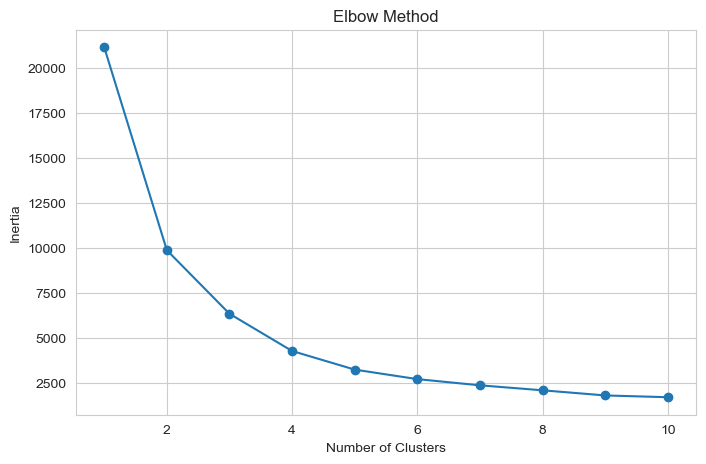

In [11]:
#plot Elbow curve 

plt.figure(figsize = (8,5))
plt.plot(K_range, inertia, marker = 'o')
plt.title('Elbow Method')
plt.xlabel ('Number of Clusters')
plt.ylabel ('Inertia')
plt.show()

In [13]:
#Apply KMeans 
kmeans = KMeans(
    n_clusters = 3, 
    random_state = 42
)
df['Cluster']= kmeans.fit_predict(scaled_features)


In [14]:
df['Cluster'].value_counts()

Cluster
2    2686
0    2183
1    2174
Name: count, dtype: int64

In [15]:
#Cluster Analysis 

Cluster_Summary = df.groupby('Cluster')[
   ['Tenure in Months',
    'Monthly Charge',
    'Total Charges'
   ]
].mean()
Cluster_Summary

,Tenure in Months,Monthly Charge,Total Charges
Cluster,,,
0,29.695831,24.377233,860.914356
1,58.589236,89.466996,5248.558648
2,13.365972,74.531199,1031.639129


In [17]:
#Segment rename 
Segment_Mapping = {
    0 : 'High Value Customers',
    1 : 'Medium value Customer',
    2 : 'Low Value Customers'
}
df['Customer_Segmentation'] = df['Cluster'].map(Segment_Mapping)
df [['Customer_Segmentation']]

,Customer_Segmentation
0,Low Value Customers
1,High Value Customers
2,Low Value Customers
3,Low Value Customers
4,Low Value Customers
...,...
7038,Low Value Customers
7039,Low Value Customers
7040,Low Value Customers
7041,Medium value Customer


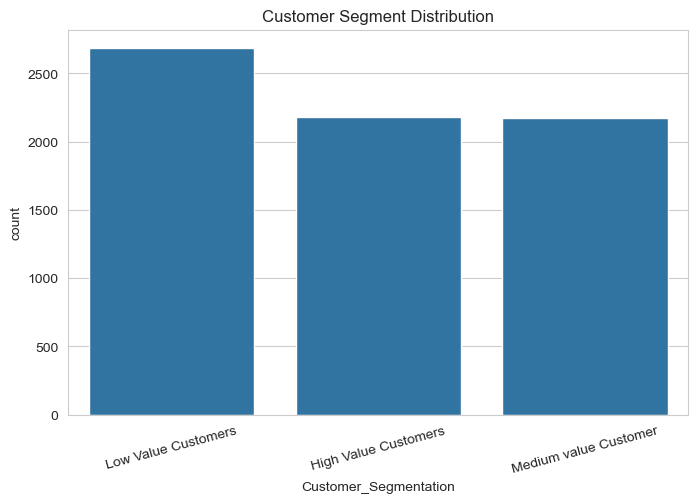

In [19]:
#Segment Distribution 

plt.figure(figsize = (8,5))
sns.countplot(
    data = df,
    x = 'Customer_Segmentation'
)
plt.xticks(rotation = 15)
plt.title('Customer Segment Distribution')
plt.show()

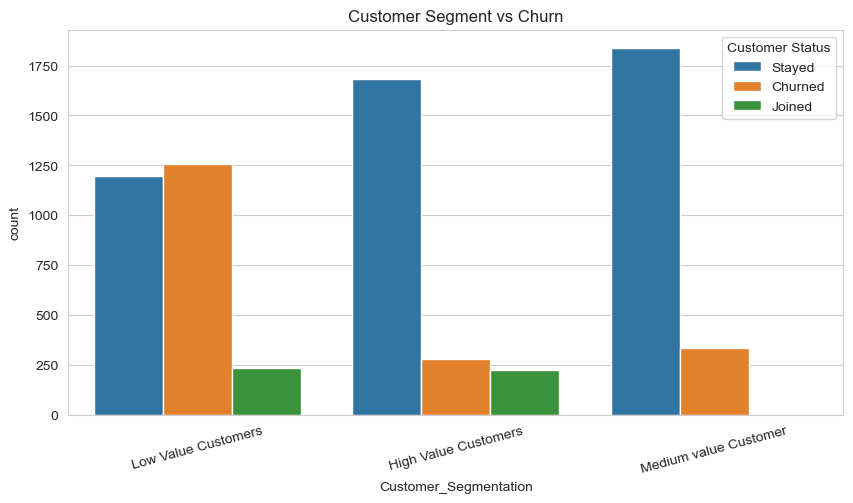

In [21]:
#Segment vs Churn 

plt.figure(figsize = (10,5))
sns.countplot(
    data = df,
    x = 'Customer_Segmentation',
    hue = 'Customer Status'
)
plt.xticks(rotation = 15)
plt.title('Customer Segment vs Churn')
plt.show()

In [22]:
df.to_csv(
    r'C:\Users\HP\Downloads\Data Analytics Projects\Final Projects\Telecom_Churn_Analysis\outputs\segmented_customers.csv',
    index=False
)